Lista 01

Questão 01:  Plote um gráfico de T por N, onde T é o tempo médio que demora para conseguirmos pelo
menos N caras consecutivas em uma sequência de lançamentos consecutivos de moedas.

Text(0, 0.5, 'tempo')

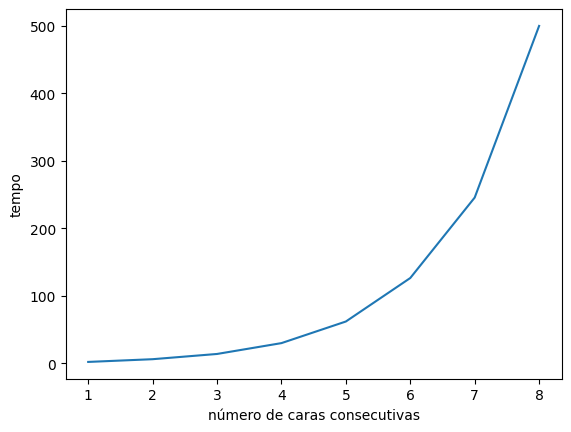

In [2]:
from numpy import random
import matplotlib.pyplot as plt

jogadas_mean = []

for i in range(1,9):
    times = []
    jogadas = []
    
    for j in range(1000):#repete para cada n 10000 vezes
        count = 0
        jogada = 0
        while count != i: # 0 = cara, 1 = coroa
            jogada += 1
            moeda = random.choice([0,1])
            if moeda == 0 : count += 1
            else : count = 0
        jogadas.append(jogada)
        
    jogadas_mean.append(sum(jogadas)/len(jogadas))

plt.plot(range(1,9),jogadas_mean)
plt.xlabel("número de caras consecutivas")
plt.ylabel("tempo")

Questão 02: No jogo Dungeons & Dragons, quando um jogador ataca um monstro, ele deve rolar um
dado de 20 lados (chamado de d20). 

a) Uma habilidade chamada “Vantagem” permite que o jogador jogue 2 dados d20 e escolha o melhor resultado. Na média, quão melhor é uma rolagem usando “Vantagem” do que uma rolagem comum (de apenas um dado)? 

b) Suponha
que um ataque como descrito acima acerta o monstro se o resultado obtido na rolagem for maior ou igual que a defesa do monstro (D). Em outras palavras, um ataque é bem sucedido se e somente se d20 >= D. Plote 2 gráficos de A por D, onde A é a porcentagem de ataques bem-sucedidos e D é o valor de defesa do monstro variando de 1 a 20, uma linha representando o ataque sem Vantagem e outra com Vantagem (veja exemplo abaixo). 

c) Você diria que a importância da habilidade “Vantagem” muda conforme D aumenta?

In [2]:
from numpy import random
import matplotlib.pyplot as plt

#letra A:

_2d20s = []
_1d20s = []
wins = 0

for i in range(10000):
    aux1 = random.choice(range(1,21))
    aux2 = random.choice(range(1,21))
    
    _2d20s.append(aux1 if aux1>aux2 else aux2)
    _1d20s.append(aux1)

mean2d20 = sum(_2d20s)/len(_2d20s)
mean1d20 = sum(_1d20s)/len(_1d20s)

print("Letra A: Há Vantagem de, em média, "+str(round(100*(mean2d20/mean1d20),2))+"%")

#vantagem de 130% 

Letra A: Há Vantagem de, em média, 131.11%


Text(0.5, 1.0, ' taxa de êxito com Vantagem VS sem Vantagem ')

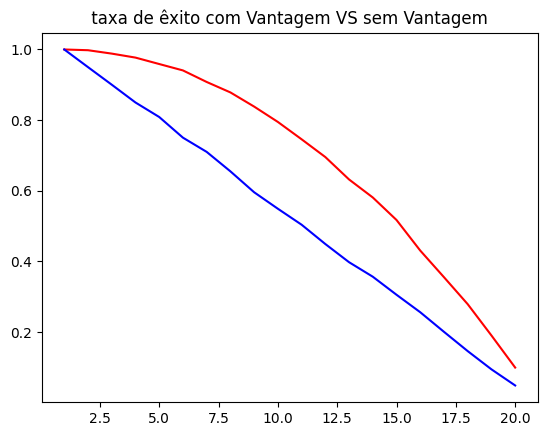

In [8]:
from numpy import random
import matplotlib.pyplot as plt

#letra B:

_2d20sAll = []
_1d20sAll = []

for j in range(1,21): # variação de D (1 a 20)
    wins2 = 0
    wins1 = 0

    for i in range(10000): 
        aux1 = random.choice(range(1,21))
        aux2 = random.choice(range(1,21))
    
        aux1 = aux2 if aux2>aux1 else aux1
    
        aux3 = random.choice(range(1,21))
        if aux1>=j : wins2 += 1
        if aux3>=j: wins1 += 1
    
    _2d20sAll.append(wins2/10000)
    _1d20sAll.append(wins1/10000)

plt.plot(range(1,21), _2d20sAll, 'r', label = 'com Vantagem')

plt.plot(range(1,21), _1d20sAll, 'b', label = 'sem Vantagem')

plt.title(" taxa de êxito com Vantagem VS sem Vantagem ")


Resposta da Letra C: A Vantagem se torna um fator relevante para um jogador ganhar dos monstros com defesas médias, mas quando um monstro possui defesas com valores extremos (próximos de 20 ou 1), essa Vantagem não influencia muito no sucesso dos ataques.

Questão 03: Suponha que você tem N moedas. Você lança todas elas aleatoriamente e elas saem como
cara ou coroa. Então, você seleciona apenas as que saíram como coroa e as lança
novamente. Depois do lançamento, você seleciona as que saíram coroa e repete o processo
até que todas saiam como cara. Simule o número esperado de lançamentos em função de N.

Text(0, 0.5, 'numero esperado de jogadas')

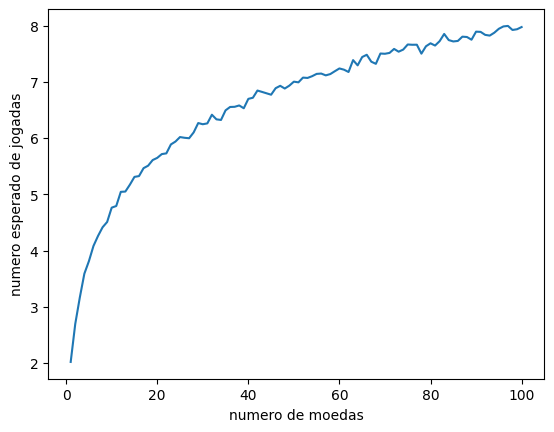

In [7]:
from numpy import random
import matplotlib.pyplot as plt

lancs = []

for a in range(1,101):
    lanc = []
    for i in range(1000):
        lancamentos = 0
        N = a
        while N>0 :
            lancamentos += 1
            moedas = random.randint(0,2,size = N)#0 = cara, 1 = coroa
            N = sum(moedas) #o sum da lista de moedas diz quantas coroas tem na lista!
        lanc.append(lancamentos)
    lancs.append(sum(lanc)/len(lanc))

plt.plot(range(1,101), lancs)
plt.xlabel("numero de moedas")
plt.ylabel("numero esperado de jogadas")

Questão 04: Mostre por simulação o curioso resultado de que, para um par de filhos A e B, a probabilidade de que ambos sejam do sexo masculino dado que um deles é do sexo masculino não é 50%.

In [8]:
from numpy import random
import matplotlib.pyplot as plt

nro_testes = 500000

#experimentos dos dois nascimentos:

twoChildren = random.randint(0,4,size = nro_testes) #0 = 2 meninas, 1 e 2 =  1 menino, 3 = 2 meninos

#filtra para os casos onde tem pelo menos um menino e evidencia como sucesso os casos que tem dois:
thereIsBoy = []

for i in twoChildren:
    if i > 0 :
        if i==2 :
            thereIsBoy.append(1)
        else:
            thereIsBoy.append(0)

print(sum(thereIsBoy)/len(thereIsBoy))
#probabilidade: 0.3333...

0.33254408839543304


Questão 05:  Uma questão interessante em teoria de probabilidade é o problema do aniversário, que
versa sobre a probabilidade de 2 pessoas de um grupo fazerem aniversário em um mesmo dia do ano. 

a) Plote um gráfico de P por N simulando a probabilidade P de 2 pessoas quaisquer fizeram aniversário no mesmo dia em um grupo de N pessoas. 

b) Plote o mesmo gráfico para 3 pessoas.


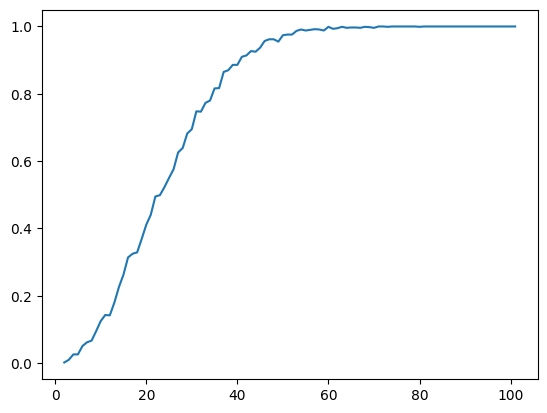

In [11]:
from numpy import random
import matplotlib.pyplot as plt

#Letra A:

def isRepeated(list):
    
    for i in range(len(list)-1):
        if list[i]==list[i+1]: 
            return 1
    
    return 0

Ptotal = []

for i in range(2,102):#N
    P = []
    
    for j in range(1000):
        aniversarios = random.randint(0,365, size = i)
        aniversarios.sort()
        
        P.append(isRepeated(aniversarios))
    
    Ptotal.append(sum(P)/len(P))


plt.plot(range(2,102),Ptotal)

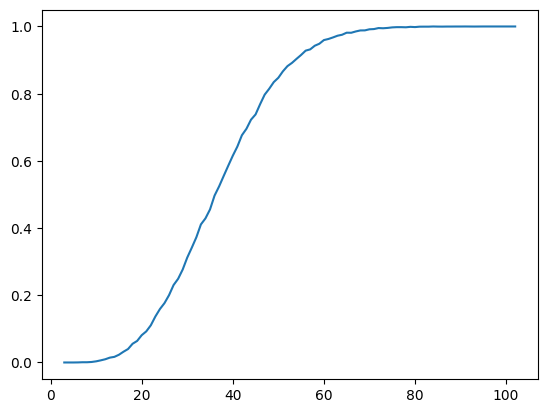

In [12]:
from numpy import random
import matplotlib.pyplot as plt

#Letra B:

def isRepeated_3(list):
    count = 0
    
    for i in range(len(list)-1):
        if count == 2:
            return 1
        
        if list[i]==list[i+1]: 
            count += 1
    
    return 0

Ptotal = []

for i in range(3,103):#N
    P = []
    
    for j in range(10000):
        aniversarios = random.randint(0,365, size = i)
        aniversarios.sort()
        
        P.append(isRepeated_3(aniversarios))
    
    Ptotal.append(sum(P)/len(P))

plt.plot(range(3,103),Ptotal)

Questão 06:  Assuma que um bêbado está abraçado a um poste no ponto de coordenada (0,0). Considere
que o bêbado decide ir para casa, mas em seu estado inebriado ele caminha 1 metro em em uma direção aleatória a cada passo. 

a) Plote o histograma do número de passos que o bêbado leva para alcançar uma distância maior que 5 metros em relação ao poste. 

b) Plote um gráfico D por N, mostrando a distância média D que o bêbado está do poste após N passos.

(array([ 51.,  80.,  99., 105.,  56.,  83.,  80.,  70.,  65.,  31.,  43.,
         36.,  34.,  20.,  11.,  21.,  17.,  12.,  14.,  12.,   9.,   7.,
          7.,   2.,   3.,   0.,   1.,   4.,   5.,   1.,   1.,   5.,   1.,
          0.,   0.,   1.,   3.,   1.,   3.,   1.,   1.,   0.,   0.,   0.,
          0.,   2.,   1.,   0.,   0.,   1.]),
 array([  6. ,   8.8,  11.6,  14.4,  17.2,  20. ,  22.8,  25.6,  28.4,
         31.2,  34. ,  36.8,  39.6,  42.4,  45.2,  48. ,  50.8,  53.6,
         56.4,  59.2,  62. ,  64.8,  67.6,  70.4,  73.2,  76. ,  78.8,
         81.6,  84.4,  87.2,  90. ,  92.8,  95.6,  98.4, 101.2, 104. ,
        106.8, 109.6, 112.4, 115.2, 118. , 120.8, 123.6, 126.4, 129.2,
        132. , 134.8, 137.6, 140.4, 143.2, 146. ]),
 <BarContainer object of 50 artists>)

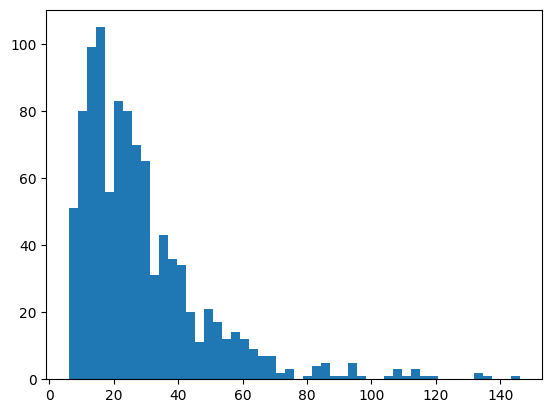

In [13]:
from numpy import random
import matplotlib.pyplot as plt
import math

#letra A:

#como o bebado pode andar em qualquer direcao circular de raio 1 metro a partir do ponto em que esta agora,
#podemos considerar aleatorizar o ângulo de caminhada do bêbado.

passosTotais = []

for i in range(1000):
    passos = 0

    partida = (0,0)

    dist = 0

    while dist<5:
    
        (x,y) = partida
    
        passos+=1
    
        angulo = random.randint(0,360)
    
        newx = x + math.cos(math.radians(angulo))
        newy = y + math.sin(math.radians(angulo))
    
        partida = (newx, newy)
        dist = math.sqrt(newx*newx + newy*newy)
    
    passosTotais.append(passos)

plt.hist(passosTotais, bins = 50)

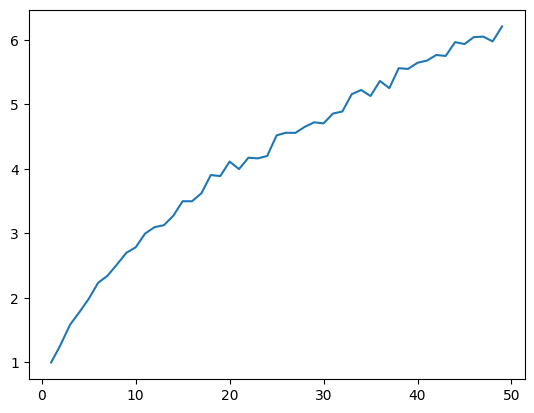

In [18]:
from numpy import random
import matplotlib.pyplot as plt
import math

#letra B:

distsTotais = []

for i in range(1, 50):
    dists = []
    
    for k in range(1000):
        partida = (0,0)
        
        dist = 0
        
        for j in range(i):
            (x,y) = partida

            angulo = random.randint(0,359)

            newx = x + math.cos(math.radians(angulo))
            newy = y + math.sin(math.radians(angulo))

            partida = (newx, newy)
            dist = math.sqrt(newx*newx + newy*newy)

        dists.append(dist)

    distsTotais.append(sum(dists)/len(dists))

plt.plot(range(1,50),distsTotais)

Questão 07:  A figura do final da lista mostra a América do Sul como um grafo de adjacências de países.

Suponha um processo markoviano em que, a cada passo, um turista viaja de um país para outro do grafo. A cada passo, o turista sai do país atual e tem probabilidade igual de escolher qualquer um dos países adjacentes como destino. 

a) Qual a probabilidade de, após um número grande de passos, o turista estar no Brasil? 

b) Quantos passos em média o turista precisa dar para visitar pelo menos uma vez cada país do grafo? 

c) Qual a probabilidade de um turista que está agora no Brasil estar ainda no Brasil daqui 2, 3 ou 4 passos? 

d) Qual a probabilidade que em uma caminhada de 10 passos começando no Brasil o turista não visite o Chile?


In [21]:
from numpy import random
import matplotlib.pyplot as plt
import math

#montagem do conjunto de dados:

cadeiaMarkov = {}
cadeiaMarkov['V'] = ['CO','G','BR']
cadeiaMarkov['G'] = ['S','BR','V']
cadeiaMarkov['S'] = ['FG','BR','G']
cadeiaMarkov['FG'] = ['S','BR']
cadeiaMarkov['BR'] = ['FG','S','G','V','CO','PE','BO','PA','A','U']
cadeiaMarkov['U'] = ['BR','A']
cadeiaMarkov['A'] = ['U','BR','BO','CH','PA']
cadeiaMarkov['PA'] = ['BO','BR','A']
cadeiaMarkov['BO'] = ['BR','CH','PE','PA','A']
cadeiaMarkov['CH'] = ['A','BO','PE']
cadeiaMarkov['PE'] = ['BR','CO','E','CH','BO']
cadeiaMarkov['E'] = ['CO','PE']
cadeiaMarkov['CO'] = ['V','PE','E','BR']

#Letra A:
#nao foi dado especificacao do estado inicial dos passos, entao escolhi equador como inicio
#numero grande de passos: 1000

N = 1000

results = []

for j in range(1000):
    estado = 'E'
    
    for i in range(N):
        idxNovoEstado = random.randint(len(cadeiaMarkov[estado]))
        listaEst = cadeiaMarkov[estado]
        estado = listaEst[idxNovoEstado]
    
    if estado == 'BR':
        results.append(1)
    else:
        results.append(0)

print('Letra A:',sum(results)/len(results))

#Letra B:

def sumDict(dict):
    sum = 0
    
    for k in dict.keys():
        sum+=dict[k]
    
    return sum

mediaPassos = []

for j in range(1000):
    visitados = {}

    for k in cadeiaMarkov.keys():
        visitados[k] = 0

    passos = 0

    estado = 'E'

    visitados[estado] = 1

    while sumDict(visitados) < 13:
        
        idxNovoEstado = random.randint(len(cadeiaMarkov[estado]))
        
        listaEst = cadeiaMarkov[estado]
        if visitados[estado] != 1 : visitados[estado] = 1
        
        passos += 1
        
        estado = listaEst[idxNovoEstado]
    
    mediaPassos.append(passos)

print('Letra B: a media de passos para visitar todos os paises eh ',sum(mediaPassos)/len(mediaPassos))

#Letra C:

result2passos = []
result3passos = []
result4passos = []

for i in range(10000):
    estado = 'BR'
    
    for j in range(2):
        idxNovoEstado = random.randint(len(cadeiaMarkov[estado]))
        listaEst = cadeiaMarkov[estado]
        estado = listaEst[idxNovoEstado]
    
    if estado == 'BR':
        result2passos.append(1)
    else:
        result2passos.append(0)
        estado = 'BR'
    
    for j in range(3):
        idxNovoEstado = random.randint(len(cadeiaMarkov[estado]))
        listaEst = cadeiaMarkov[estado]
        estado = listaEst[idxNovoEstado]
    
    if estado == 'BR':
        result3passos.append(1)
    else:
        result3passos.append(0)
        estado = 'BR'
    
    for j in range(4):
        idxNovoEstado = random.randint(len(cadeiaMarkov[estado]))
        listaEst = cadeiaMarkov[estado]
        estado = listaEst[idxNovoEstado]
    
    if estado == 'BR':
        result4passos.append(1)
    else:
        result4passos.append(0)

print('Letra C: probabilidade de estar no brasil, saindo do brasil em: \n-2 passos:',sum(result2passos)/len(result2passos),
        '\n-3 passos:',sum(result3passos)/len(result3passos),
        '\n-4 passos:',sum(result4passos)/len(result4passos),
        '\nE para 2,3 ou 4 passos:',sum(result2passos)/len(result2passos)+sum(result3passos)/len(result3passos)+sum(result4passos)/len(result4passos))

#Letra D:
result = []

for i in range(10000):
    estado = 'BR'
    flag = True
    
    for j in range(10):
        idxNovoEstado = random.randint(len(cadeiaMarkov[estado]))
        listaEst = cadeiaMarkov[estado]
        estado = listaEst[idxNovoEstado]
        
        if estado == 'CH':
            result.append(0)
            flag = False #passou no chile
            break
    
    if flag:
        result.append(1)

print('Letra D: probabilidade de, saindo do brasil, nao passar pelo chile eh:',sum(result)/len(result))

Letra A: 0.213
Letra B: a media de passos para visitar todos os paises eh  61.864
Letra C: probabilidade de estar no brasil, saindo do brasil em: 
-2 passos: 0.3217 
-3 passos: 0.166 
-4 passos: 0.2299 
E para 2,3 ou 4 passos: 0.7176
Letra D: probabilidade de, saindo do brasil, nao passar pelo chile eh: 0.6335


Questão 08:  

No jogo banco imobiliário, você joga 2d6 (obtendo um resultado de 2 a 12) e anda esse
número de espaços ao redor do tabuleiro (veja por exemplo a imagem do tabuleiro no final desta lista). Os espaços com retângulos coloridos representam propriedades imobiliárias (ignore os efeitos dos outros espaços). 

a) Considerando que uma partida de Banco Imobiliário demora um tempo tendendo a infinito (como qualquer pessoa que já jogou Banco Imobiliário pode confirmar), qual a probabilidade de cairmos em cada propriedade após um número muito grande de jogadas? 

b) Considerando agora que ao parar no espaço do canto superior direito do tabuleiro (“vá para a prisão”), o jogador é transportado para o espaço inferior esquerdo (“prisão”), simule novamente as probabilidades. 

c) Considerando que as melhores propriedades imobiliárias são aquelas onde os jogadores param com frequência, qual você diria que é a melhor cor de propriedades no tabuleiro?

In [2]:
from numpy import random
import matplotlib.pyplot as plt
import math
import numpy as np

def setTabuleiroCircular():
    tabuleiro = {t:0 for t in range(40)}
    
    #bota como 1 as posicoes que nao sao retangulo colorido, para simbolizar quais
    #posicoes precisam ser visitadas
    tabuleiro[0] = 1
    tabuleiro[2] = 1
    tabuleiro[5] = 1
    tabuleiro[7] = 1
    tabuleiro[10] = 1
    tabuleiro[12] = 1
    tabuleiro[15] = 1
    tabuleiro[16] = 1
    tabuleiro[18] = 1
    tabuleiro[20] = 1
    tabuleiro[22] = 1
    tabuleiro[24] = 1
    tabuleiro[25] = 1
    tabuleiro[27] = 1
    tabuleiro[30] = 1
    tabuleiro[32] = 1
    tabuleiro[35] = 1
    tabuleiro[37] = 1
    
    return tabuleiro

#Letra A:

probCadaRetangulo = []

resultTeste = {}

for i in range(40):
    resultTeste[i] = []

for j in range(100):#multiplos testes
    tabuleiroCircular = setTabuleiroCircular()
    
    locAtual = 0#a primeira posicao é dita como 0 aqui, mas esse 0 não é o primeiro retangulo!
    #ele é só um estado inicial
    
    for k in range(1000):#numero grande de jogadas
        dado1 = random.randint(1,7)
        dado2 = random.randint(1,7)
        locAtual = (locAtual + dado1 + dado2)%40
        
        tabuleiroCircular[locAtual] = 1
    
    for i in range(40):
        resultTeste[i].append(tabuleiroCircular[i])

for i in range(40):
    probCadaRetangulo.append(sum(resultTeste[i])/len(resultTeste[i]))

print('Letra A: probabilidade de cair nas propriedades:')

tab = setTabuleiroCircular()
for i in tab:
    if tab[i] == 0:
        print('retangulo',i,':',probCadaRetangulo[i])

Letra A: probabilidade de cair nas propriedades:
retangulo 1 : 1.0
retangulo 3 : 1.0
retangulo 4 : 1.0
retangulo 6 : 1.0
retangulo 8 : 1.0
retangulo 9 : 1.0
retangulo 11 : 1.0
retangulo 13 : 1.0
retangulo 14 : 1.0
retangulo 17 : 1.0
retangulo 19 : 1.0
retangulo 21 : 1.0
retangulo 23 : 1.0
retangulo 26 : 1.0
retangulo 28 : 1.0
retangulo 29 : 1.0
retangulo 31 : 1.0
retangulo 33 : 1.0
retangulo 34 : 1.0
retangulo 36 : 1.0
retangulo 38 : 1.0
retangulo 39 : 1.0


In [17]:
#Letra B:

probCadaRetangulo = []

resultTeste = {}

for i in range(40):
    resultTeste[i] = []

for j in range(100):#multiplos testes
    tabuleiroCircular = setTabuleiroCircular()
    
    locAtual = 0#a primeira posicao é dita como 0 aqui, mas esse 0 não é o primeiro retangulo!
    #ele é só um estado inicial
    
    for k in range(1000):#numero grande de jogadas
        if locAtual == 30:
            locAtual = 10
        else:
            dado1 = random.randint(1,7)
            dado2 = random.randint(1,7)
            locAtual = (locAtual + dado1 + dado2)%40
        
        tabuleiroCircular[locAtual] = 1
    
    for i in range(40):
        resultTeste[i].append(tabuleiroCircular[i])

for i in range(40):
    probCadaRetangulo.append(sum(resultTeste[i])/len(resultTeste[i]))

print('Letra B: probabilidade de cair nas propriedades:')

tab = setTabuleiroCircular()
for i in tab:
    if tab[i] == 0:
        print('retangulo',i,':',probCadaRetangulo[i])

Letra A: probabilidade de cair nas propriedades:
retangulo 1 : 1.0
retangulo 3 : 1.0
retangulo 4 : 1.0
retangulo 6 : 1.0
retangulo 8 : 1.0
retangulo 9 : 1.0
retangulo 11 : 1.0
retangulo 13 : 1.0
retangulo 14 : 1.0
retangulo 17 : 1.0
retangulo 19 : 1.0
retangulo 21 : 1.0
retangulo 23 : 1.0
retangulo 26 : 1.0
retangulo 28 : 1.0
retangulo 29 : 1.0
retangulo 31 : 1.0
retangulo 33 : 1.0
retangulo 34 : 1.0
retangulo 36 : 1.0
retangulo 38 : 1.0
retangulo 39 : 1.0


In [8]:
#Letra C

#calcular a frequência de cada cor de propriedade!

coresTabuleiro = [-1,0,-1,0,0,-1,1,-1,1,1,-1,
                    2,-1,2,2,-1,-1,3,-1,3,-1,4,-1,4,-1,-1,5,-1,5,5,-1,6,-1,6,6,-1,6,-1,7,7]

freqCoresTotais = {}
for i in range(8):
    freqCoresTotais[i] = []

for j in range(100):#multiplos testes
    locAtual = 0#a primeira posicao é dita como 0 aqui, mas esse 0 não é o primeiro retangulo!
    #ele é só um estado inicial
    freqCores = {cor: 0 for cor in range(8)}
    
    for k in range(1000):#numero grande de jogadas
        dado1 = random.randint(1,7)
        dado2 = random.randint(1,7)
        locAtual = (locAtual + dado1 + dado2)%40
        
        if coresTabuleiro[locAtual] != -1:
            freqCores[coresTabuleiro[locAtual]] += 1
    
    for k in range(8):
        freqCoresTotais[k].append(freqCores[k])


for i in range(8):
    print("cor",i,":",sum(freqCoresTotais[i])/100,"por jogo;")

#acho que a melhor cor de propriedades é a verde escuro, pois é a mais frequentada (faz sentido, pensando que existem mais
#propriedades dessa cor)


cor 0 : 75.7 por jogo;
cor 1 : 73.8 por jogo;
cor 2 : 74.59 por jogo;
cor 3 : 50.06 por jogo;
cor 4 : 49.68 por jogo;
cor 5 : 75.66 por jogo;
cor 6 : 101.18 por jogo;
cor 7 : 49.49 por jogo;


Questão 09: 

a) Os times de futebol Vermelho FC e Azul FC jogam uma partida. Suponha que os times marcam gols de forma independente seguindo processos de Poisson com taxas de chegada λv = 2/partida e λa = 3/partida. Qual a taxa de partidas que podemos esperar que o time Vermelho FC ganha? 

b) Resolva o mesmo exercício para os times de basquete RedCats e BlueDogs, assumindo taxas de chegada de pontos de λr = 100/partida e λb = 150/partida, respondendo quantas vezes podemos esperar que o time RedCats ganha. 

c) Compare os resultados e explique

In [22]:
from numpy import random
import numpy as np
import matplotlib.pyplot as plt
import math

#Letra A:

#supondo t = 1 pois é uma partida

partidasVganha = 0

for i in range(100000):
    golsV = random.poisson(1/2)
    golsA = random.poisson(1/3)
    
    if golsV > golsA: partidasVganha += 1



print('LETRA A: taxa de ganhos de Vermelho FC:',partidasVganha/1000,'%')

#Letra B:

partidasRedCatsganha = 0

for i in range(100000):
    RedCats = random.poisson(1/100)
    BlueDogs = random.poisson(1/150)
    
    if RedCats > BlueDogs: partidasRedCatsganha += 1

print('LETRA B: taxa de ganhos de RedCats:',partidasRedCatsganha/1000,'%')

print('LETRA C: a diferença monstruosa na taxa da letra A para a letra B se deve ao fato de que, mesmo que as taxas dos dois times\n',
        'estejam na mesma proporcionalidade (2:3), há muitos mais eventos possíveis entre redCats e blueDogs, que entre vermelho FC e azul FC,\n',
        'fazendo com que o time que tenha a vantagem de 50 gols a mais na taxa na letra B fique na vanguarda na esmagadora maioria dos testes.')

LETRA A: taxa de ganhos de Vermelho FC: 30.641 %
LETRA B: taxa de ganhos de RedCats: 0.973 %
LETRA C: a diferença monstruosa na taxa da letra A para a letra B se deve ao fato de que, mesmo que as taxas dos dois times
 estejam na mesma proporcionalidade (2:3), há muitos mais eventos possíveis entre redCats e blueDogs, que entre vermelho FC e azul FC,
 fazendo com que o time que tenha a vantagem de 50 gols a mais na taxa na letra B fique na vanguarda na esmagadora maioria dos testes.
